# Ejercicio Ridge, Lasso y ElasticNet
Para este ejercicio vas a trabajar con datos de ventas de una empresa que fabrica muebles en España. Esta empresa es una Pyme que demanda conocer de antemano qué ingresos va a tener cada mes, ya que necesita pedir un anticipio a su entidad financiera de cara a poder abastecerse de materia prima al comenzar el mes. Como desconoce cuánto tiene que pedir, tira al alza y acaba pagando muchos intereses. El objetivo es reducir estos gastos.

En las bases de datos de la empresa constan todos los gastos en publicidad y ventas, para cada uno de los meses desde su fundación (hace más de 15 años).

Dado que los presupuestos de marketing se cierran al principio de cada mes, la empresa necesita un modelo predictivo que le anticipe las ventas que conseguirá a final de mes en función de los gastos que realizará en marketing.

Para ello tendrás que utilizar tanto modelos de regresión normales, como regularizados.

1. Carga los datos y realiza un pequeño análisis exploratorio. Mira a ver cómo se relaciona las ventas con el resto de variables.
2. Crea varios modelos y modifica los hiperparámetros necesarios para mejorar el performance del modelo.
3. Interpreta los resultados. Traduce a una fórmula tu mejor modelo (escribir la fórmula simplemente). ¿Cuánto cambian las ventas si aumentamos la inversión en radio un punto más? ¿Y si aumentamos la inversión en TV o periódicos?

## Import libraries 

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures, StandardScaler, MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## Exploratory Data Analysis 

In [28]:
# Lectura datos, relación variables, mapas de correlación...

In [29]:
adver = pd.read_csv(r"C:\Users\data_\2026-02-BILBAO-FT-Data-Science\3-Machine_Learning\1-Supervisado\1-Regression\3-Regularization\ejercicios\data\Advertising.csv")
adver

,Unnamed: 0,TV,radio,newpaper,sales
0,0,230.1,37.8,6s9.2,22100.0
1,1,44.5,39.3,45.1,10400.0
2,2,17.2,45.9,69.3,9300.0
3,3,151.5,41.3,58.5,18500.0
4,4,180.8,10.8,58.4,12900.0
...,...,...,...,...,...
195,195,38.2,3.7,13.8,7600.0
196,196,94.2,4.9,8.1,9700.0
197,197,177.0,9.3,6.4,12800.0
198,198,283.6,42.0,66.2,25500.0


In [30]:
# Eliminar la columna 'Unnamed: 0':
if 'Unnamed: 0' in adver.columns:
    adver = adver.drop(columns=['Unnamed: 0'])

print("Info del Dataset:")
print(adver.info())
print("\nPrimeras filas:")
display(adver.head())

Info del Dataset:
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   TV        200 non-null    float64
 1   radio     200 non-null    float64
 2   newpaper  200 non-null    str    
 3   sales     200 non-null    float64
dtypes: float64(3), str(1)
memory usage: 6.4 KB
None

Primeras filas:


,TV,radio,newpaper,sales
0,230.1,37.8,6s9.2,22100.0
1,44.5,39.3,45.1,10400.0
2,17.2,45.9,69.3,9300.0
3,151.5,41.3,58.5,18500.0
4,180.8,10.8,58.4,12900.0


In [31]:
# 1. Aseguramos que los nombres de las columnas sean correctos: 'TV', 'radio', 'newpaper', 'sales'
adver.columns = adver.columns.str.strip() # Quita espacios vacíos en los nombres

# 2. Forzamos a que todo sea número. 
# Si hay algún texto perdido en las filas, se convertirá en NaN y luego lo borramos.
adver = adver.apply(pd.to_numeric, errors='coerce')
adver = adver.dropna()

# 3. Graficamos de nuevo (asegúrate de usar los nombres exactos que imprimas abajo)
print("Columnas disponibles:", adver.columns.tolist())

Columnas disponibles: ['TV', 'radio', 'newpaper', 'sales']


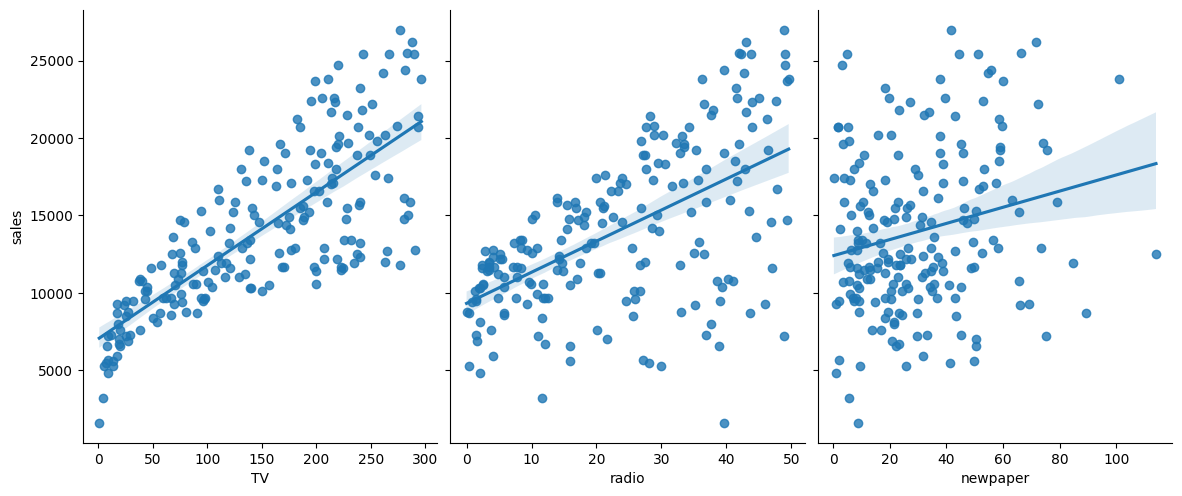

In [32]:
# 2. Relación de variables (Pairplot)
# La mejor forma de ver cómo cada canal influye en las ventas de un vistazo es un pairplot. Buscamos tendencias lineales.

sns.pairplot(adver, x_vars=['TV', 'radio', 'newpaper'], y_vars='sales', height=5, aspect=0.8, kind='reg')
plt.show()

# TV: Muestra una relación lineal muy fuerte y clara con Sales.
# radio: También tiene relación positiva, aunque con un poco más de dispersión.
# newpaper: Los puntos están muy dispersos; la relación parece mucho más débil

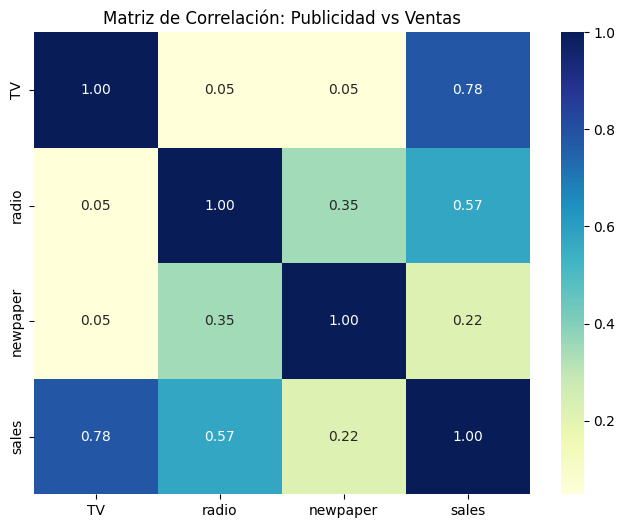

In [33]:
# 3. Mapa de Correlación (Heatmap)

plt.figure(figsize=(8, 6))
sns.heatmap(adver.corr(), annot=True, cmap='YlGnBu', fmt=".2f")
plt.title("Matriz de Correlación: Publicidad vs Ventas")
plt.show()

# Coeficiente TV-sales: es el más alto (0.78), confirmando que es el motor principal de ventas.
# Multicolinealidad: Revisa si TV, radio o newpaper están correlacionados entre sí. Si los coeficientes entre ellos son bajos (cercanos a 0), es ideal para la regresión:
# TV con radio y newpaper tienen coeficientes de 0.05
# radio con newpaper tiene coeficiente de 0.35

## Modelado

In [34]:
# Manipulación datasets, entrenamiento, evaluación, nuevas iteraciones... Prueba modelos sin y con regularización.

In [35]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

In [36]:
# Para mejorar el rendimiento del modelo, compararemos una Regresión Lineal simple (sin regularización) frente a Ridge y Lasso (con regularización). 
# La regularización ayudará a controlar si alguna variable (como newpaper) está añadiendo ruido.
# 1. Preparación de los datos:
# Dividimos en entrenamiento y prueba, asegurándonos de que los datos estén limpios.

# Definir variables (ajusta los nombres a tu dataset si varían)
X = adver[['TV', 'radio', 'newpaper']]
y = adver['sales']

# Dividir datos (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# IMPORTANTE: Para Ridge y Lasso, debemos escalar los datos
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [38]:
# 2. Entrenamiento y comparación de modelos
# Probaremos tres aproximaciones para ver cuál da mejor resultado:

# Definir los modelos:
models = {"Lineal (Sin Reg.)": LinearRegression(), "Ridge (L2)": Ridge(alpha=1.0), "Lasso (L1)": Lasso(alpha=0.1)}
results = {}

for name, model in models.items():
    # Entrenar (usamos los datos escalados para todos por consistencia)
    model.fit(X_train_scaled, y_train)
    
    # Predecir
    y_pred = model.predict(X_test_scaled)
    
    # Evaluar
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    results[name] = {'RMSE': rmse, 'R2': r2}

# Mostrar resultados
df_results = pd.DataFrame(results).T
print(df_results)



                          RMSE        R2
Lineal (Sin Reg.)  1587.484753  0.873384
Ridge (L2)         1578.755857  0.874772
Lasso (L1)         1587.433932  0.873392


In [ ]:
# 3. Ajuste de Hiperparámetros (Iteración)
# Si el modelo Lasso o Ridge no mejora mucho, podemos probar diferentes valores de alpha (fuerza de la penalización).

# Ejemplo de nueva iteración con Lasso variando alpha
for a in [0.01, 0.1, 1, 10]:
    ls = Lasso(alpha=a)
    ls.fit(X_train_scaled, y_train)
    score = ls.score(X_test_scaled, y_test)
    print(f"Lasso con alpha={a}: R2 = {score:.4f}")

# Análisis de la mejora:
# Sin Regularización: Si el modelo ya es bueno, Ridge y Lasso darán resultados similares.
# Con Lasso: Observa los coeficientes (model.coef_). Lasso tiene la particularidad de que puede hacer que el coeficiente de newpaper sea exactamente 0, 
# eliminándolo de facto si no aporta valor.
# Con Ridge: Útil si sospechas que hay mucha relación entre las variables (aunque aquí vimos que no hay tanta).

Lasso con alpha=0.01: R2 = 0.8734
Lasso con alpha=0.1: R2 = 0.8734
Lasso con alpha=1: R2 = 0.8735
Lasso con alpha=10: R2 = 0.8741


### Modelos Polinómicos

In [ ]:
# Los modelos polinómicos son muy interesantes porque a veces el efecto combinado de dos canales (ej. invertir en TV y radio al mismo tiempo)
# es mayor que la suma de sus partes. Esto se llama efecto de interacción.
# Vamos a crear modelos polinómicos de grado 2 y aplicaremos regularización para evitar que el modelo se vuelva demasiado complejo.

# 1. Generación de Características Polinómicas
# Transformaremos las 3 variables originales en 9 (incluyendo cuadrados e interacciones).

from sklearn.preprocessing import PolynomialFeatures

# 1. Crear el transformador (grado 2)
# interaction_only=False incluye cuadrados (TV^2) e interacciones (TV*Radio)
poly = PolynomialFeatures(degree=2, include_bias=False)

X_train_poly = poly.fit_transform(X_train_scaled)
X_test_poly = poly.transform(X_test_scaled)

print(f"Nuevas variables generadas: {X_train_poly.shape[1]}")

Nuevas variables generadas: 9


In [39]:
# 2. Entrenamiento y Comparativa
# Probaremos el modelo Polinómico "puro" vs. versiones con regularización (Ridge y Lasso).

poly_models = {"Polinómico Puro": LinearRegression(), "Polinómico + Ridge": Ridge(alpha=5.0), "Polinómico + Lasso": Lasso(alpha=0.1)}
poly_results = {}

for name, model in poly_models.items():
    model.fit(X_train_poly, y_train)
    y_pred = model.predict(X_test_poly)
    
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    poly_results[name] = {'RMSE': rmse, 'R2': r2}

# Mostrar resultados comparados
df_poly_results = pd.DataFrame(poly_results).T
print("Resultados Modelos Polinómicos (Grado 2):")
print(df_poly_results)

Resultados Modelos Polinómicos (Grado 2):
                          RMSE        R2
Polinómico Puro     626.393240  0.980286
Polinómico + Ridge  600.273208  0.981896
Polinómico + Lasso  626.202144  0.980298


In [41]:
# 3. ¿Por qué esto suele mejorar el performance?
# En el dataset de publicidad, el modelo polinómico captura el hecho de que:
# Sinergia: La inversión en radio potencia la efectividad de la inversión en TV.
# Saturación: El efecto de la TV puede no ser infinito (curvatura).
# Análisis de Coeficientes (Lasso Polinómico)
# Lasso es especialmente útil aquí porque de las 9 nuevas variables, seleccionará solo las que realmente importan:

# Ver qué variables seleccionó Lasso Polinómico
lasso_poly = poly_models["Polinómico + Lasso"]
feature_names = poly.get_feature_names_out(['TV', 'radio', 'newpaper'])

coef_df = pd.DataFrame({'Feature': feature_names, 'Coef': lasso_poly.coef_})
print("\nCoeficientes de Lasso Polinómico (variables filtradas):")
print(coef_df[coef_df['Coef'] != 0]) # Solo las que no son cero


Coeficientes de Lasso Polinómico (variables filtradas):
          Feature         Coef
0              TV  3803.387987
1           radio  2895.834738
2        newpaper   119.589280
3            TV^2  -830.977083
4        TV radio  1471.763035
5     TV newpaper  -144.948819
6         radio^2     0.677193
7  radio newpaper    50.903717
8      newpaper^2    -6.075874


## Resultados

In [269]:
# Interpreta, resume y destaca los puntos importantes de los resultados.

In [ ]:
# Hecho en las celdas anteriores mientras se ha ido haciendo el ejercicio